In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [14]:
df = pd.read_csv('data/processed_data.csv')

## Exploratory Data Analysis

In [20]:
df.head()

,Product,Complaint_text,Company_response_to_consumer,Timely_response,Consumer_disputed,Complaint_ID,high_priority
0,Credit card,I have a Fidelity credit card which I paid aut...,Closed with non-monetary relief,Yes,No,2117730,0
1,Credit card,I responded to a credit card application on th...,Closed with explanation,Yes,No,9647146,0
2,Credit card,Opened Carter 's Credit card when buying cloth...,Closed with explanation,Yes,No,16289273,0
3,Credit card,In accordance with the fair credit reporting a...,Closed with explanation,Yes,No,7794318,0
4,Credit card,Chase sapphire supposedly provides XXXX servic...,Closed with explanation,Yes,No,17076061,0


In [15]:
df.shape

(105650, 7)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105650 entries, 0 to 105649
Data columns (total 7 columns):
 #   Column                        Non-Null Count   Dtype
---  ------                        --------------   -----
 0   Product                       105650 non-null  str  
 1   Complaint_text                105650 non-null  str  
 2   Company_response_to_consumer  105650 non-null  str  
 3   Timely_response               105650 non-null  str  
 4   Consumer_disputed             105650 non-null  str  
 5   Complaint_ID                  105650 non-null  int64
 6   high_priority                 105650 non-null  int64
dtypes: int64(2), str(5)
memory usage: 5.6 MB


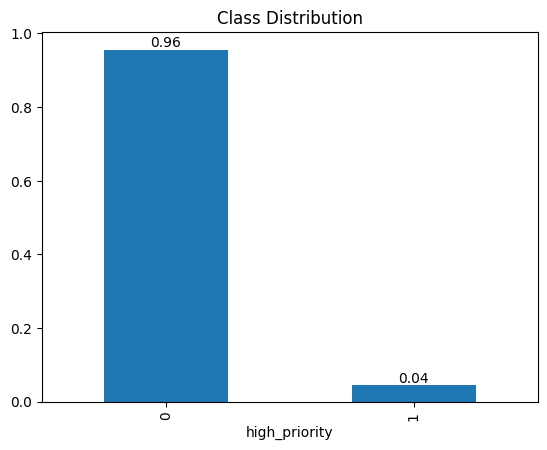

In [17]:
ax = df.high_priority.value_counts(normalize=True).plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=0)
plt.title('Class Distribution')
plt.show()

In [18]:
df.isna().sum().sort_values(ascending=False)

Product                         0
Complaint_text                  0
Company_response_to_consumer    0
Timely_response                 0
Consumer_disputed               0
Complaint_ID                    0
high_priority                   0
dtype: int64

## Split data

In [22]:
df_full_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df['high_priority'], random_state=3
)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, stratify=df_full_train['high_priority'], random_state=3
)

X_train, y_train = df_train.drop(columns=['high_priority']), df_train['high_priority']
X_val, y_val = df_val.drop(columns=['high_priority']), df_val['high_priority']
X_test, y_test = df_test.drop(columns=['high_priority']), df_test['high_priority']

In [28]:
text_col = 'Complaint_text'   # change if needed

X_train_text = X_train[text_col].astype(str)
X_val_text   = X_val[text_col].astype(str)
X_test_text  = X_test[text_col].astype(str)

In [32]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9,
        max_features=20000
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train_text, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [33]:
from sklearn.metrics import roc_auc_score

y_val_proba = pipeline.predict_proba(X_val_text)[:, 1]
roc_auc = roc_auc_score(y_val, y_val_proba)
roc_auc

0.8568882476501667

In [34]:
def precision_at_k(y_true, y_score, k_frac=0.10):
    k = max(1, int(k_frac * len(y_true)))
    top_idx = np.argsort(y_score)[-k:]
    return y_true.iloc[top_idx].mean()

p_at_10 = precision_at_k(y_val, y_val_proba, k_frac=0.10)
p_at_15 = precision_at_k(y_val, y_val_proba, k_frac=0.15)
p_at_20 = precision_at_k(y_val, y_val_proba, k_frac=0.20)

p_at_10, p_at_15, p_at_20

(np.float64(0.21344060577378135),
 np.float64(0.18207636478384348),
 np.float64(0.1575958353052532))

In [35]:
y_test_proba = pipeline.predict_proba(X_test_text)[:, 1]
test_auc = roc_auc_score(y_test, y_test_proba)
test_p_at_10 = precision_at_k(y_test, y_test_proba, k_frac=0.10)

test_auc, test_p_at_10

(0.8576075141493588, np.float64(0.21012778040700425))

In [37]:
top_k = int(0.10 * len(y_test))
top_idx = np.argsort(y_test_proba)[-top_k:]
recall_at_10 = y_test.iloc[top_idx].sum() / y_test.sum()
recall_at_10

np.float64(0.47690655209452204)

In [38]:
from src.model import ComplaintPriorityModel

m = ComplaintPriorityModel()

m.predict_proba('I was charged twice and nobody helped me')

0.06720272301395194